In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [10]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [11]:
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [12]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

## Observations

- The average customer age is approximately **41 years**.
- The average total purchase amount is **456**.
- On average, customers purchase around **2 to 3 products** per transaction.
- The average price per unit is approximately **179.89**.
- These statistics provide an overview of customer purchasing behavior and product pricing.

# Time Series Analysis

In this section, we analyze sales over time to identify monthly and quarterly trends. This helps businesses understand seasonal demand and make better inventory and marketing decisions.

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 90.4 KB


In [16]:
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter

In [17]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2


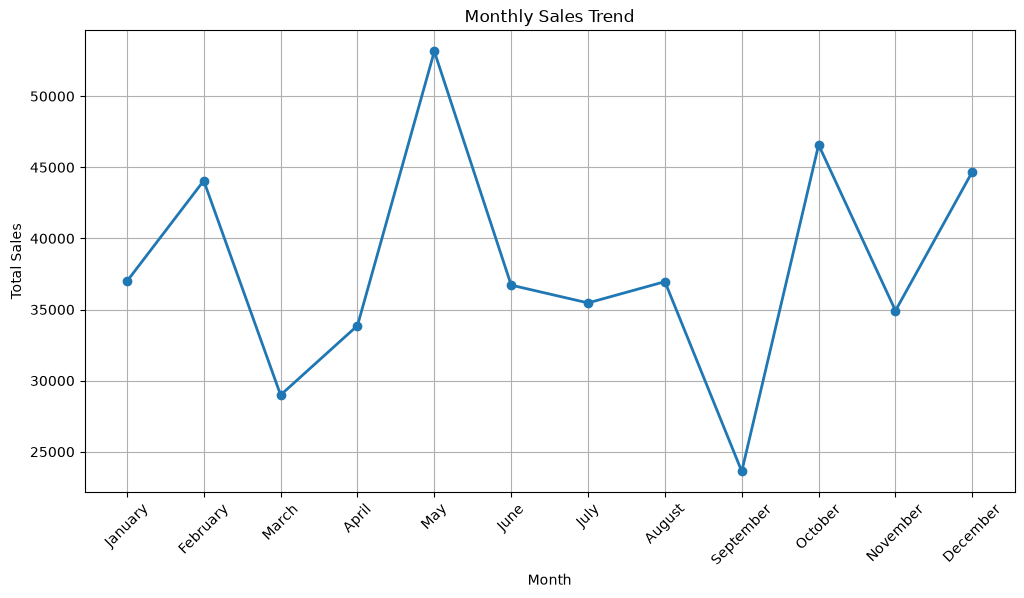

In [18]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Observation

- The monthly sales show noticeable fluctuations throughout the year.
- Sales reached their highest value in **May**, indicating a peak sales period.
- **September** recorded the lowest sales, suggesting a decline in customer purchases during that month.
- Businesses can use these insights to plan inventory, marketing campaigns, and promotional offers during low-sales months.

# Quarterly Sales Trend

This section analyzes total sales across different quarters of the year to identify broader business trends.

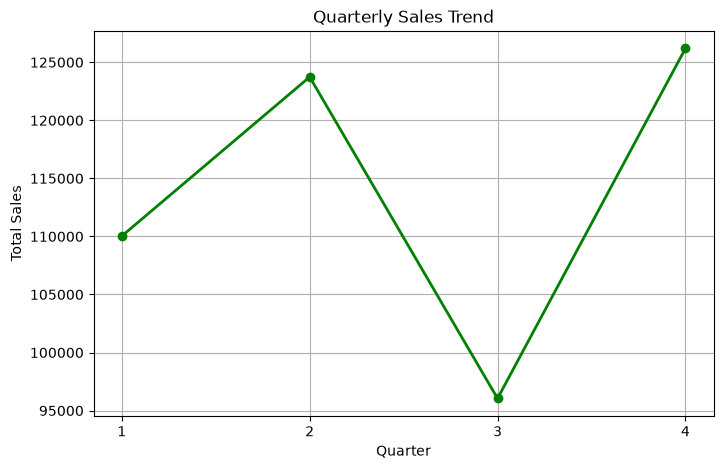

In [19]:
# Quarterly Sales Trend

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))

plt.plot(quarterly_sales.index,
         quarterly_sales.values,
         marker='o',
         linewidth=2,
         color='green')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks([1,2,3,4])

plt.grid(True)

plt.show()

## Observation

- Quarterly sales vary across the year.
- One quarter generated higher revenue than the others, indicating stronger customer demand.
- Businesses can use quarterly trends for financial planning and forecasting future sales.

# Customer Demographics Analysis

This section analyzes customer demographics, including age distribution and gender distribution, to better understand customer characteristics and purchasing patterns.

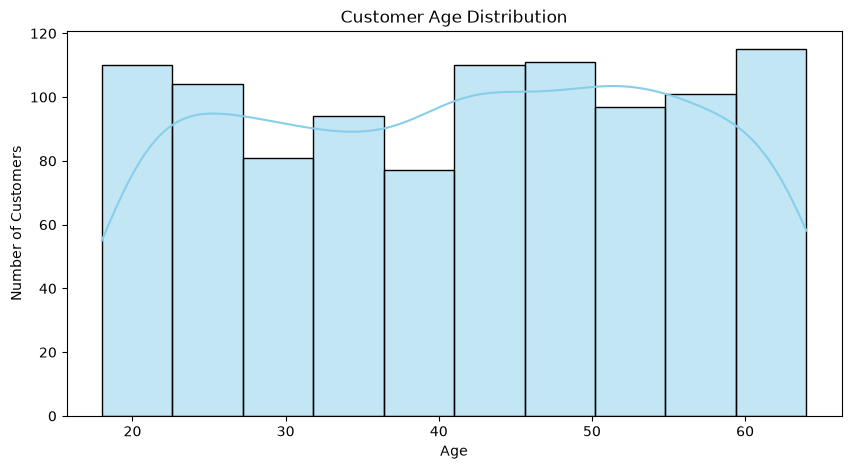

In [20]:
# Customer Age Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Observation

- Customers belong to different age groups, with most falling within the adult age range.
- The age distribution provides insights into the target customer segment.
- Businesses can use this information to design age-specific marketing campaigns and product recommendations.

# Gender Distribution

This section analyzes the distribution of customers based on gender.

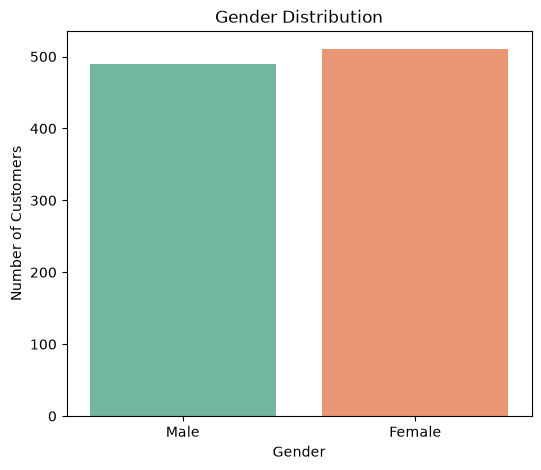

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    hue='Gender',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Observation

- The chart shows the distribution of male and female customers.
- Understanding gender distribution helps businesses tailor products and promotional campaigns.
- The customer base appears to include both male and female shoppers, indicating a diverse market.

# Product Analysis

This section analyzes product performance by identifying the top-selling products and comparing revenue generated by different product categories.

In [23]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

# Revenue by Product Category

This section compares the total revenue generated by each product category to identify the highest-performing category.

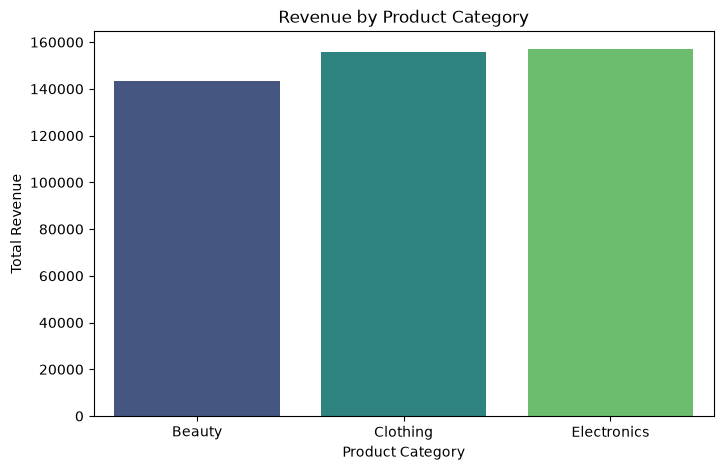

In [24]:
# Revenue by Product Category

category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette='viridis',
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

## Observation

- The chart compares total revenue generated by each product category.
- The category with the highest revenue contributes the most to overall sales.
- Businesses can focus on high-performing categories while developing strategies to improve lower-performing categories.

# Sales Count by Product Category

This chart shows the number of transactions for each product category.

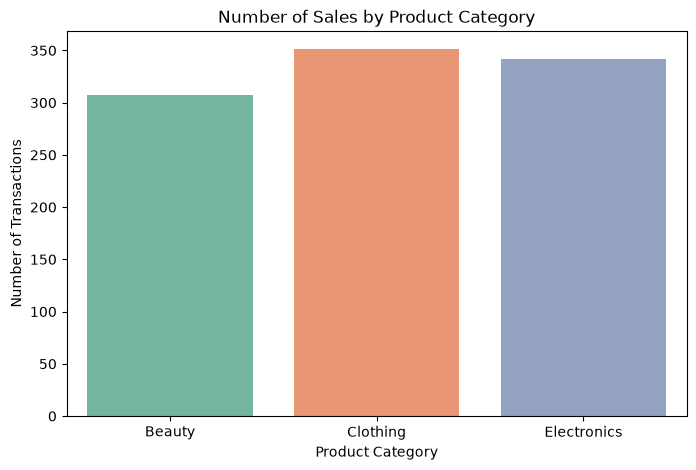

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Product Category',
    data=df,
    hue='Product Category',
    palette='Set2',
    legend=False
)

plt.title("Number of Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.show()

## Observation

- Clothing has the highest number of transactions.
- Electronics and Beauty also contribute significantly to total sales.
- The distribution suggests that all three categories are important to the business.

**Note:** The selected dataset contains product categories instead of individual product names. Therefore, product category analysis has been performed in place of top-selling product analysis.

# Correlation Analysis

This section examines the relationship between numerical variables using a correlation heatmap. It helps identify whether changes in one variable are associated with changes in another.

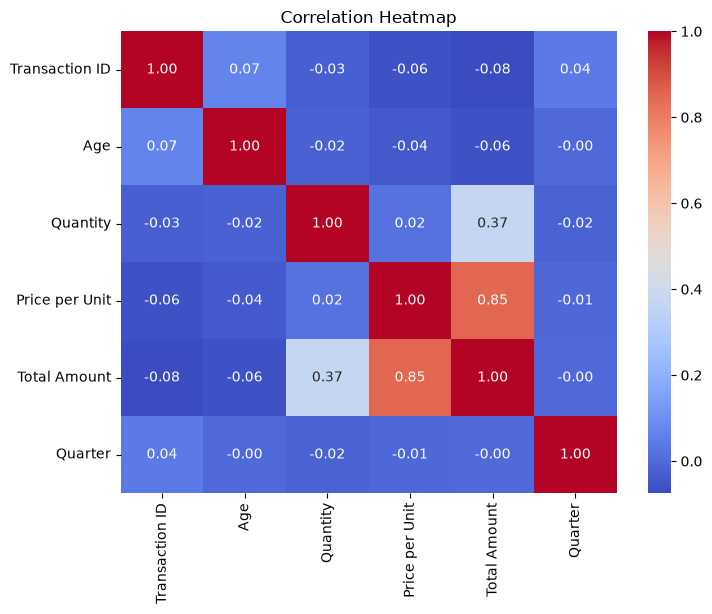

In [26]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- The heatmap shows the correlation between numerical variables in the dataset.
- A stronger positive correlation indicates that two variables tend to increase together.
- Variables with weak correlation have little influence on each other.
- The heatmap helps identify relationships useful for business analysis and decision-making.

# Additional Visualization – Box Plot

This box plot helps identify the distribution of total purchase amounts and detect any outliers in customer spending.

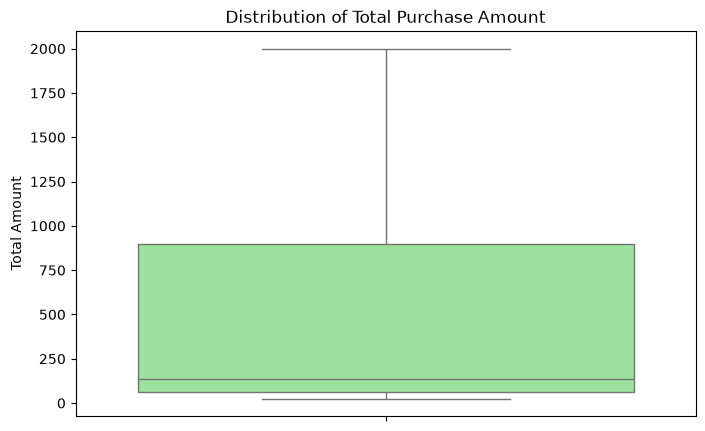

In [27]:
# Box Plot for Total Amount

plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Total Amount'],
    color='lightgreen'
)

plt.title("Distribution of Total Purchase Amount")

plt.ylabel("Total Amount")

plt.show()

## Observation

- The box plot shows the spread of customer purchase amounts.
- A few high-value purchases appear as outliers.
- Most transactions fall within a lower spending range.
- This insight can help businesses identify premium customers and spending patterns.

# Business Recommendations

Based on the analysis, the following recommendations are suggested:

1. Increase promotional campaigns during months with lower sales to improve revenue.

2. Focus marketing efforts on the highest-performing product category while developing strategies to improve lower-performing categories.

3. Design personalized marketing campaigns for the dominant customer age group and continue offering products that appeal to both male and female customers.

4. Monitor high-value purchases and reward loyal customers through membership or discount programs.

5. Use monthly and quarterly sales trends for inventory planning and demand forecasting.

# Conclusion

This Exploratory Data Analysis (EDA) examined retail sales data to identify customer demographics, sales trends, and product performance. The analysis showed variations in monthly and quarterly sales, differences in revenue across product categories, and customer purchasing behavior. The insights gained from this analysis can support better business decisions, improve marketing strategies, optimize inventory management, and enhance customer engagement.